In [54]:
import pandas as pd

In [55]:
df = pd.read_csv("data/gsearch_jobs.csv", encoding='latin1', on_bad_lines='skip')

In [56]:
df.head()

,Unnamed: 0,index,title,company_name,location,via,description,extensions,job_id,thumbnail,...,commute_time,salary_pay,salary_rate,salary_avg,salary_min,salary_max,salary_hourly,salary_yearly,salary_standardized,description_tokens
0,0,0,Data Analyst,Meta,Anywhere,via LinkedIn,In the intersection of compliance and analytic...,"['15 hours ago', '101Kâ143K a year', 'Work f...",eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QiLCJodGlkb2...,https://encrypted-tbn0.gstatic.com/images?q=tb...,...,NaN,101Kâ143K,a year,122000.0,101000.0,143000.0,NaN,122000.0,122000.0,"['tableau', 'r', 'python', 'sql']"
1,1,1,Data Analyst,ATC,United States,via LinkedIn,Job Title: Entry Level Business Analyst / Prod...,"['12 hours ago', 'Full-time', 'Health insurance']",eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QiLCJodGlkb2...,https://encrypted-tbn0.gstatic.com/images?q=tb...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[]
2,2,2,Aeronautical Data Analyst,"Garmin International, Inc.","Olathe, KS",via Indeed,Overview:\n\nWe are seeking a full-time...\nAe...,"['18 hours ago', 'Full-time']",eyJqb2JfdGl0bGUiOiJBZXJvbmF1dGljYWwgRGF0YSBBbm...,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,['sql']
3,3,3,Data Analyst - Consumer Goods - Contract to Hire,Upwork,Anywhere,via Upwork,Enthusiastic Data Analyst for processing sales...,"['12 hours ago', '15â25 an hour', 'Work from...",eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QgLSBDb25zdW...,NaN,...,NaN,15â25,an hour,20.0,15.0,25.0,20.0,NaN,41600.0,"['powerpoint', 'excel', 'power_bi']"
4,4,4,Data Analyst | Workforce Management,Krispy Kreme,United States,via LinkedIn,Overview of Position\n\nThis position will be ...,"['7 hours ago', '90Kâ110K a year', 'Contract...",eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QgfCBXb3JrZm...,https://encrypted-tbn0.gstatic.com/images?q=tb...,...,NaN,90Kâ110K,a year,100000.0,90000.0,110000.0,NaN,100000.0,100000.0,"['powerpoint', 'excel', 'outlook', 'word']"


In [57]:
df.columns

Index(['Unnamed: 0', 'index', 'title', 'company_name', 'location', 'via',
       'description', 'extensions', 'job_id', 'thumbnail', 'posted_at',
       'schedule_type', 'work_from_home', 'salary', 'search_term', 'date_time',
       'search_location', 'commute_time', 'salary_pay', 'salary_rate',
       'salary_avg', 'salary_min', 'salary_max', 'salary_hourly',
       'salary_yearly', 'salary_standardized', 'description_tokens'],
      dtype='str')

In [58]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 61953 entries, 0 to 61952
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           61953 non-null  int64  
 1   index                61953 non-null  int64  
 2   title                61953 non-null  str    
 3   company_name         61953 non-null  str    
 4   location             61916 non-null  str    
 5   via                  61944 non-null  str    
 6   description          61953 non-null  str    
 7   extensions           61953 non-null  str    
 8   job_id               61953 non-null  str    
 9   thumbnail            38194 non-null  str    
 10  posted_at            61763 non-null  str    
 11  schedule_type        61707 non-null  str    
 12  work_from_home       27980 non-null  object 
 13  salary               10088 non-null  str    
 14  search_term          61953 non-null  str    
 15  date_time            61953 non-null  str    
 1

In [59]:
df.isnull().sum()

Unnamed: 0                 0
index                      0
title                      0
company_name               0
location                  37
via                        9
description                0
extensions                 0
job_id                     0
thumbnail              23759
posted_at                190
schedule_type            246
work_from_home         33973
salary                 51865
search_term                0
date_time                  0
search_location            0
commute_time           61953
salary_pay             51865
salary_rate            51865
salary_avg             51865
salary_min             52441
salary_max             52441
salary_hourly          56053
salary_yearly          57884
salary_standardized    51865
description_tokens         0
dtype: int64

In [60]:
#Drop useless columns
df = df.drop(columns=['Unnamed: 0', 'index', 'job_id', 'thumbnail', 'commute_time', 'description_tokens'])

In [61]:
# Handle missing location
df['location'] = df['location'].fillna('Unknown')

In [62]:
#Keep only rows with salary

df = df[df['salary_standardized'].notnull()] 

In [63]:
# Create a clean numeric salary column
df['clean_salary'] = df['salary_standardized'].astype(int)

In [64]:
df[['title','company_name', 'location', 'salary', 'salary_standardized', 'clean_salary']].head()

,title,company_name,location,salary,salary_standardized,clean_salary
0,Data Analyst,Meta,Anywhere,101Kâ143K a year,122000.0,122000
3,Data Analyst - Consumer Goods - Contract to Hire,Upwork,Anywhere,15â25 an hour,41600.0,41600
4,Data Analyst | Workforce Management,Krispy Kreme,United States,90Kâ110K a year,100000.0,100000
10,Senior Data Analyst,Aquent,Anywhere,54.00â60.52 an hour,119100.8,119100
14,Mid-level Claims Data Analyst,CIBA Insurance Services,United States,90Kâ130K a year,110000.0,110000


In [65]:
df.shape

(10088, 22)

In [66]:
df.isnull().sum()

title                     0
company_name              0
location                  0
via                       9
description               0
extensions                0
posted_at               121
schedule_type            27
work_from_home         3778
salary                    0
search_term               0
date_time                 0
search_location           0
salary_pay                0
salary_rate               0
salary_avg                0
salary_min              576
salary_max              576
salary_hourly          4188
salary_yearly          6019
salary_standardized       0
clean_salary              0
dtype: int64

In [67]:
# Removing all salary redundant(that has many null) columns, keeping only clean_salary column
df = df.drop(columns=['salary', 'salary_pay', 'salary_rate', 'salary_avg', 'salary_min', 'salary_max', 'salary_avg', 'salary_hourly', 'salary_hourly', 'salary_standardized', 'salary_yearly'])

In [69]:
df.info()

<class 'pandas.DataFrame'>
Index: 10088 entries, 0 to 61952
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   title            10088 non-null  str   
 1   company_name     10088 non-null  str   
 2   location         10088 non-null  str   
 3   via              10079 non-null  str   
 4   description      10088 non-null  str   
 5   extensions       10088 non-null  str   
 6   posted_at        9967 non-null   str   
 7   schedule_type    10061 non-null  str   
 8   work_from_home   6310 non-null   object
 9   search_term      10088 non-null  str   
 10  date_time        10088 non-null  str   
 11  search_location  10088 non-null  str   
 12  clean_salary     10088 non-null  int64 
dtypes: int64(1), object(1), str(11)
memory usage: 1.1+ MB


In [74]:
# Cleaning job titles
# Function to categorize job titles into standard roles

def clean_title(title):
    title = title.lower()

# Check if title contains data analyst
    if 'data analyst' in title:
        return 'Data Analyst'

# Check if title contains data scientist
    elif 'data scientist' in title:
        return 'Data Scientist'
    
# Check if title contains data engineer   
    elif 'data engineer' in title:
        return 'Data Engineer'
    
# Check if title contains machine learning engineer   
    elif 'machine learning' in title or 'ml engineer' in title:
        return 'ML Engineer'

# Everything else goes into 'other'
    else:
        return 'Other'



In [76]:
# Apply the function to create a new column
df['clean_title'] = df['title'].apply(clean_title)

In [77]:
# Extract skills from description

# List of important skills to search for
skills=['python', 'sql', 'excel', 'tableau', 'power bi', 'aws']

#Loop through each skill
for skill in skills:

    # Create a new column for each skill
    # True if skill is found in description, False otherwise
    df[skill]= df['description'].str.contains(skill, case=False, na=False)

In [78]:
df.head()

,title,company_name,location,via,description,extensions,posted_at,schedule_type,work_from_home,search_term,date_time,search_location,clean_salary,clean_title,python,sql,excel,tableau,power bi,aws
0,Data Analyst,Meta,Anywhere,via LinkedIn,In the intersection of compliance and analytic...,"['15 hours ago', '101Kâ143K a year', 'Work f...",15 hours ago,Full-time,True,data analyst,2023-08-04 03:00:13.797776,United States,122000,Data Analyst,True,True,False,True,False,False
3,Data Analyst - Consumer Goods - Contract to Hire,Upwork,Anywhere,via Upwork,Enthusiastic Data Analyst for processing sales...,"['12 hours ago', '15â25 an hour', 'Work from...",12 hours ago,Contractor,True,data analyst,2023-08-04 03:00:13.797776,United States,41600,Data Analyst,False,False,True,False,True,False
4,Data Analyst | Workforce Management,Krispy Kreme,United States,via LinkedIn,Overview of Position\n\nThis position will be ...,"['7 hours ago', '90Kâ110K a year', 'Contract...",7 hours ago,Contractor,NaN,data analyst,2023-08-04 03:00:13.797776,United States,100000,Data Analyst,False,False,True,False,False,False
10,Senior Data Analyst,Aquent,Anywhere,via LinkedIn,The Research Data Analyst is responsible for d...,"['14 hours ago', '54.00â60.52 an hour', 'Wor...",14 hours ago,NaN,True,data analyst,2023-08-04 03:00:19.724974,United States,119100,Data Analyst,False,True,True,False,False,False
14,Mid-level Claims Data Analyst,CIBA Insurance Services,United States,via KSNT Jobs,"Established in 1993, CIBA Insurance Services o...","['10 hours ago', '90Kâ130K a year', 'Full-ti...",10 hours ago,Full-time,NaN,data analyst,2023-08-04 03:00:19.724974,United States,110000,Data Analyst,False,True,True,False,False,False


In [81]:
# Analyze job role distribution
# count how many job belong to each clean_job category
# value_counts() counts occurances of each unique value

role_counts= df['clean_title'].value_counts()
role_counts

clean_title
Data Analyst      5974
Other             3551
Data Scientist     410
Data Engineer      145
ML Engineer          8
Name: count, dtype: int64

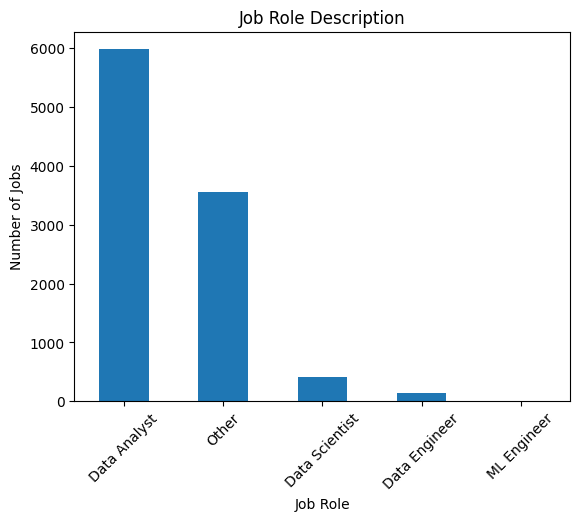

In [86]:
# Import matplotlib for plotting charts
import matplotlib.pyplot as plt

# create a bar chart from role_counts
# kind='bar' creates a bar chart

role_counts.plot(kind='bar')

# Add chart title
plt.title('Job Role Description')

# Label x-axis
plt.xlabel('Job Role')

#label y-axis
plt.ylabel('Number of Jobs')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Display the chart
plt.show()

In [82]:
# Analyze salary by job role
# Group data by job role (clean_title)
# Then calculate average salary for each role

salary_by_role= df.groupby('clean_title')['clean_salary'].mean()

# sort the results from highest salary to lowest
salary_by_role= salary_by_role.sort_values(ascending=False)

# Display result
salary_by_role

clean_title
ML Engineer       146240.000000
Data Scientist    135019.009756
Data Engineer     131363.579310
Other              95005.731062
Data Analyst       86721.538165
Name: clean_salary, dtype: float64

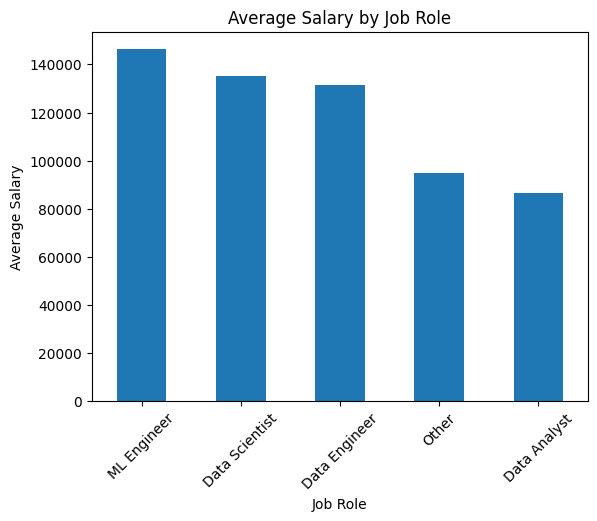

In [87]:
# Create bar chart for salary comparison
salary_by_role.plot(kind='bar')

# Add chart title
plt.title('Average Salary by Job Role')

# Label x-axis
plt.xlabel('Job Role')

# Label y-axis
plt.ylabel('Average Salary')

# Rotate labels for readability
plt.xticks(rotation=45)

# Show chart
plt.show()

In [83]:
# skill demad Analysis
# list of skills we want to analyze
skills= ['python', 'sql', 'excel', 'tableau', 'power bi', 'aws']

# loop through each skills
for skill in skills:
    
    # count how many jobs require this skill
    # df[skill] is a True/False column
    # sum() counts how many true value exists

    print(skill, df[skill].sum())

python 2540
sql 4643
excel 4918
tableau 2638
power bi 1627
aws 1139


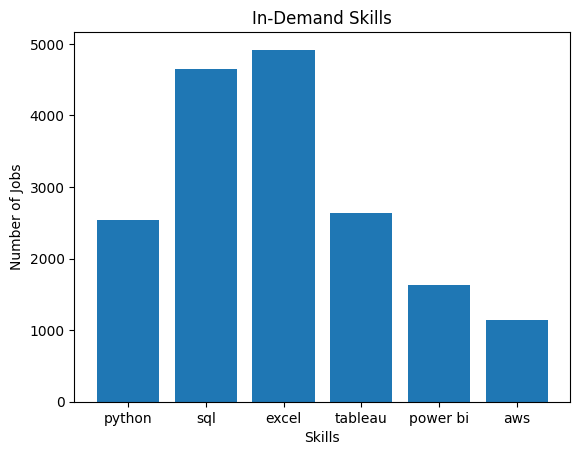

In [88]:
# Create a dictionary to store skill counts
skill_counts = {}

# Loop again to store results in dictionary
for skill in skills:
    
    # Store count of each skill
    skill_counts[skill] = df[skill].sum()

# Create bar chart
plt.bar(skill_counts.keys(), skill_counts.values())

# Add title
plt.title('In-Demand Skills')

# Label x-axis
plt.xlabel('Skills')

# Label y-axis
plt.ylabel('Number of Jobs')

# Show chart
plt.show()

In [84]:
# Analyze top job locations
# count how many jobs located in each locations
location_counts= df['location'].value_counts()

In [85]:
# show top 10 locations
location_counts.head(10)

location
 Anywhere                  4116
Anywhere                   2196
  United States             881
United States               583
  Oklahoma City, OK         153
  Jefferson City, MO        130
Denver, CO                  101
Grand Junction, CO           82
  Kansas City, MO            81
Colorado Springs, CO         48
Name: count, dtype: int64

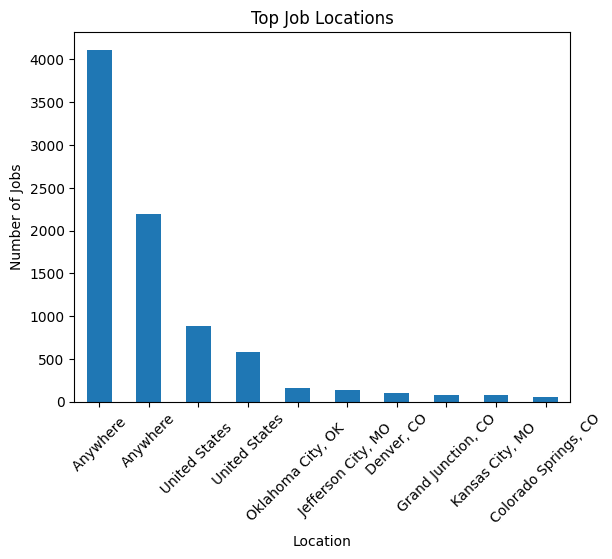

In [90]:
# Plot top 10 locations as bar chart
location_counts.head(10).plot(kind='bar')

# Add chart title
plt.title('Top Job Locations')

# Label x-axis
plt.xlabel('Location')

# Label y-axis
plt.ylabel('Number of Jobs')

# Rotate labels for readability
plt.xticks(rotation=45)

# Show chart
plt.show()